# F1 AI/ML Series — Part 2: The Pit Wall 🏁

**Goal:** Build a data pipeline that analyses the 2026 F1 season using the FastF1 API.

**What this notebook covers:**
- Loading official F1 session data
- Finding the fastest lap
- Lap time progression across the race
- Gap to leader (timing tower)
- Tyre strategy visualisation
- ERS mode detection via Speed vs RPM delta

In [2]:
import fastf1
import fastf1.plotting
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import warnings
import os

warnings.filterwarnings("ignore")

CACHE_DIR = "./f1_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
fastf1.Cache.enable_cache(CACHE_DIR)

print("Cache enabled!")

Cache enabled!


## Step 1 — Loading the Session Data
We load the 2026 Australian GP Race session. 
First load is slow (~2-3 mins) as it downloads from F1's servers.
Subsequent loads are instant from cache.

In [3]:
session = fastf1.get_session(2026, "Australia", "R")
session.load()

print(f"Loaded: {session.event['EventName']}")
print(f"Location: {session.event['Location']}, {session.event['Country']}")

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No

Loaded: Australian Grand Prix
Location: Melbourne, Australia


## Step 2 — Exploring the Data Structure
Before analysing anything, we look at what columns are available.
`session.laps` gives us every lap from every driver as a DataFrame.

In [4]:
laps = session.laps

print(f"Total laps in session: {len(laps)}")
print(f"\nColumns available:")
print(list(laps.columns))

Total laps in session: 1006

Columns available:
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']


## Step 3 — Fastest Lap
Finding the fastest lap of the entire race, and the fastest lap per driver.

In [5]:
fastest_lap = laps.pick_fastest()

print(f"Fastest Lap Driver: {fastest_lap['Driver']}")
print(f"Lap Time: {fastest_lap['LapTime']}")
print(f"Lap Number: {int(fastest_lap['LapNumber'])}")
print(f"Compound: {fastest_lap['Compound']}")
print(f"Tyre Age: {int(fastest_lap['TyreLife'])} laps old")

Fastest Lap Driver: VER
Lap Time: 0 days 00:01:22.091000
Lap Number: 43
Compound: HARD
Tyre Age: 2 laps old


### Fastest Lap Per Driver

In [6]:
fastest_per_driver = (
    laps.groupby("Driver")
    .apply(lambda x: x.pick_fastest())
    .reset_index(drop=True)
    [["Driver", "LapTime", "LapNumber", "Compound", "TyreLife"]]
    .sort_values("LapTime")
)

print(fastest_per_driver.to_string(index=False))

Driver                LapTime  LapNumber Compound  TyreLife
   VER 0 days 00:01:22.091000       43.0     HARD       2.0
   NOR 0 days 00:01:22.358000       53.0   MEDIUM      19.0
   ANT 0 days 00:01:22.417000       57.0     HARD      45.0
   HAM 0 days 00:01:22.423000       55.0     HARD      27.0
   LEC 0 days 00:01:22.579000       38.0     HARD      13.0
   RUS 0 days 00:01:22.670000       21.0     HARD       9.0
   COL 0 days 00:01:22.926000       48.0     SOFT       2.0
   BOR 0 days 00:01:23.257000       45.0     HARD      12.0
   SAI 0 days 00:01:23.590000       52.0     SOFT       7.0
   LAW 0 days 00:01:23.783000       47.0     SOFT      14.0
   BEA 0 days 00:01:24.020000       22.0     HARD       4.0
   LIN 0 days 00:01:24.182000       21.0     HARD       3.0
   ALB 0 days 00:01:24.375000       36.0     SOFT       3.0
   OCO 0 days 00:01:24.424000       25.0     HARD      14.0
   GAS 0 days 00:01:24.486000       56.0     HARD      45.0
   HAD 0 days 00:01:25.239000        9.0

### Observation 💡
VER and NOR set the fastest individual laps, but the race was won by Russell and the second place went to Antonelli.
This shows the difference between raw one-lap pace and race pace — 
tyre management, strategy and consistency matter more than peak speed over a full race distance.

## Step 4 — Lap Time Progression
Plotting how each top 5 driver's lap times changed across the race.
Slower laps = tyre degradation or traffic. Sudden slow lap = pit stop.

req            INFO 	Using cached data for driver_info


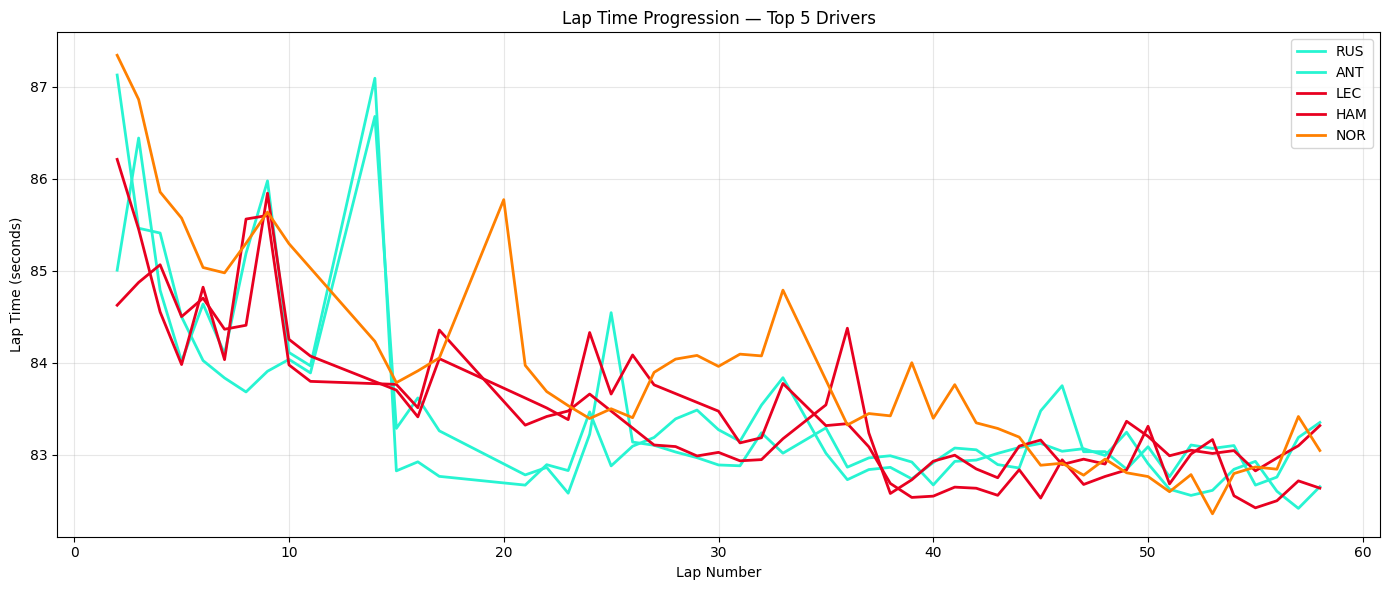

In [7]:
top5_drivers = session.results["Abbreviation"].head(5).tolist()

fig, ax = plt.subplots(figsize=(14, 6))

for driver in top5_drivers:
    driver_laps = laps.pick_drivers(driver).pick_quicklaps()
    driver_laps = driver_laps.copy()
    driver_laps["LapTimeSeconds"] = driver_laps["LapTime"].dt.total_seconds()
    
    color = fastf1.plotting.get_driver_color(driver, session)
    ax.plot(
        driver_laps["LapNumber"],
        driver_laps["LapTimeSeconds"],
        label=driver,
        color=color,
        linewidth=2
    )

ax.set_title("Lap Time Progression — Top 5 Drivers")
ax.set_xlabel("Lap Number")
ax.set_ylabel("Lap Time (seconds)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("lap_time_progression.png", dpi=150)
plt.show()

### Observation 💡
Laps 1-15 are slower since the drivers have higher fuel loads while  battling with other drivers for positions, another point to know that their tires are not yet warmed up but after those initial laps and drivers spacing  out and fuel decreases, we get faster lap times.
As u can see some spikes do come in some laps that shows the driver pitted for new tires (a good trade off in the long run)

## Step 5 — Gap to Leader
How far behind the race leader is each top 5 driver at every lap.
Calculated by cumulative sum of lap times — the driver with the lowest 
cumulative time at any lap is the leader.

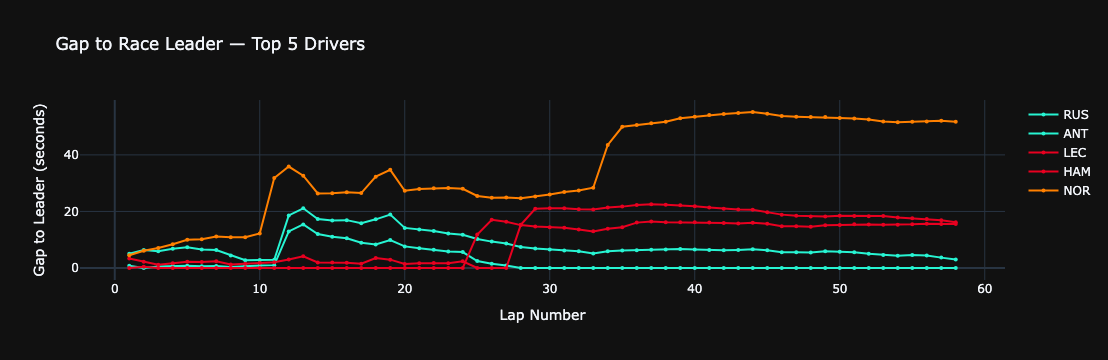

In [9]:
def compute_gaps_to_leader(laps_df, drivers):
    lap_numbers = sorted(laps_df["LapNumber"].unique())
    gap_data = {}

    for lap in lap_numbers:
        lap_slice = laps_df[laps_df["LapNumber"] == lap]
        lap_times = {}
        for drv in drivers:
            drv_lap = lap_slice[lap_slice["Driver"] == drv]
            if not drv_lap.empty and pd.notna(drv_lap.iloc[0]["LapTime"]):
                lap_times[drv] = drv_lap.iloc[0]["LapTime"].total_seconds()
        gap_data[lap] = lap_times

    df = pd.DataFrame(gap_data).T
    df_cumulative = df.cumsum()
    leader_time = df_cumulative.min(axis=1)
    gap_to_leader = df_cumulative.subtract(leader_time, axis=0)
    return gap_to_leader

gap_df = compute_gaps_to_leader(laps, top5_drivers)
gap_df = gap_df.dropna(how="all")

fig = go.Figure()
for driver in top5_drivers:
    if driver not in gap_df.columns:
        continue
    color = fastf1.plotting.get_driver_color(driver, session)
    fig.add_trace(go.Scatter(
        x=gap_df.index,
        y=gap_df[driver],
        mode="lines+markers",
        name=driver,
        line=dict(color=color, width=2),
        marker=dict(size=4),
    ))

fig.update_layout(
    title="Gap to Race Leader — Top 5 Drivers",
    xaxis_title="Lap Number",
    yaxis_title="Gap to Leader (seconds)",
    template="plotly_dark",
    hovermode="x unified",
)
fig.write_html("gap_to_leader.html")
fig.show()

### Observation 💡
The gap chart tells the story of the race strategy battle.
Leclerc held the lead in the early phase but Ferrari's aggressive 
pit strategy compromised his track position, once he pitted, Hamilton 
briefly inherited the lead before Russell emerged ahead after cycling 
through his stops cleanly.

Russell then led consistently to the end, with Antonelli closely 
mirroring his gap, a direct reflection of Mercedes running near identical 
strategies for both drivers. Teammates on the same strategy show up clearly 
as parallel lines on this chart.

## Step 6 — Tyre Strategy
Visualising each driver's stint length and compound choices.
Each bar = one stint. Colour = tyre compound.
Pit stops appear as the gap between bars.

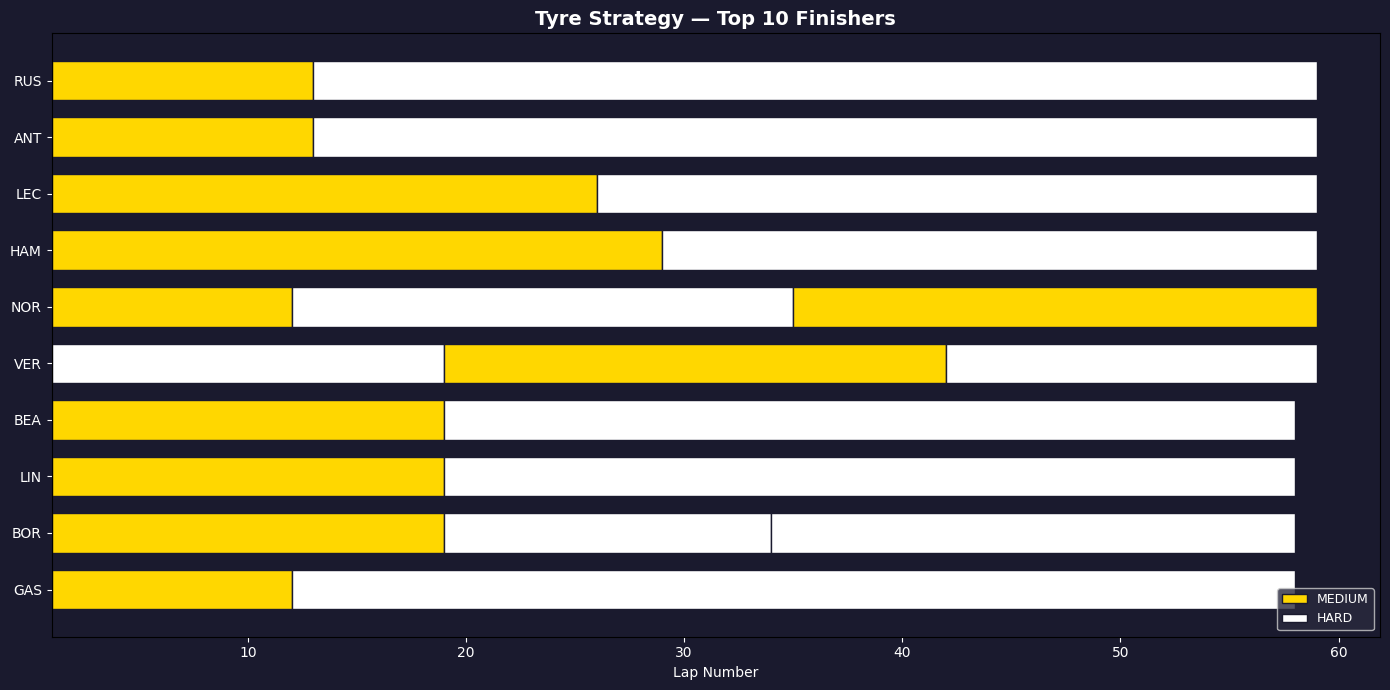

In [11]:
COMPOUND_COLORS = {
    "SOFT": "#FF3333",
    "MEDIUM": "#FFD700",
    "HARD": "#FFFFFF",
    "INTERMEDIATE": "#39B54A",
    "WET": "#0067FF",
    "UNKNOWN": "#999999",
}

top10_drivers = session.results["Abbreviation"].tolist()[:10]

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor("#1a1a2e")
ax.set_facecolor("#1a1a2e")

for i, driver in enumerate(reversed(top10_drivers)):
    driver_laps = laps.pick_drivers(driver)
    stints = driver_laps.groupby("Stint")

    for stint_num, stint_laps in stints:
        compound = stint_laps["Compound"].iloc[0]
        start_lap = stint_laps["LapNumber"].min()
        end_lap = stint_laps["LapNumber"].max()
        color = COMPOUND_COLORS.get(compound, "#999999")

        ax.barh(
            y=i,
            width=end_lap - start_lap + 1,
            left=start_lap,
            color=color,
            edgecolor="#1a1a2e",
            height=0.7,
            label=compound,
        )

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), 
          loc="lower right", facecolor="#2a2a3e", 
          labelcolor="white", fontsize=9)

ax.set_yticks(range(len(top10_drivers)))
ax.set_yticklabels(list(reversed(top10_drivers)), color="white")
ax.set_xlabel("Lap Number", color="white")
ax.set_title("Tyre Strategy — Top 10 Finishers", 
             color="white", fontsize=14, fontweight="bold")
ax.tick_params(colors="white")
plt.tight_layout()
plt.savefig("tyre_strategy.png", dpi=150, 
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### Observation 💡
The tyre strategy chart reveals exactly how Mercedes won the race.
Russell and Antonelli both pitted earlier than Ferrari, executing a 
classic undercut — emerging on fresh tyres with clean air ahead while 
Leclerc and Hamilton were still on degrading rubber.

Ferrari's delayed pit response meant they lost track position they 
couldn't recover. The 1-2 finish for Mercedes was built in the pit lane, 
not on the track.

Notably, Verstappen started on Hard tyres — a sign he started outside 
the top 10 and chose an alternative strategy, switching to Medium during 
the Safety Car window before returning to Hards for the final stint.
    
Norris ran an unusual Medium-Hard-Medium strategy — the only driver 
in the top 5 to return to a softer compound in the final stint. 
This may indicate a tyre issue or an aggressive 3-stop gamble by 
McLaren, though the exact reasoning would require post-race team 
radio data to confirm.

## Step 7 — ERS Mode Detection
Analysing Speed vs RPM delta on the fastest lap to detect when 
the car is harvesting energy (recharging) vs deploying it (boosting).
Since 2026 regulations restrict direct ERS telemetry, this is a 
proxy method using available sensor data.

ERS_Mode
Neutral     125
Recharge    115
Boost        73
Name: count, dtype: int64


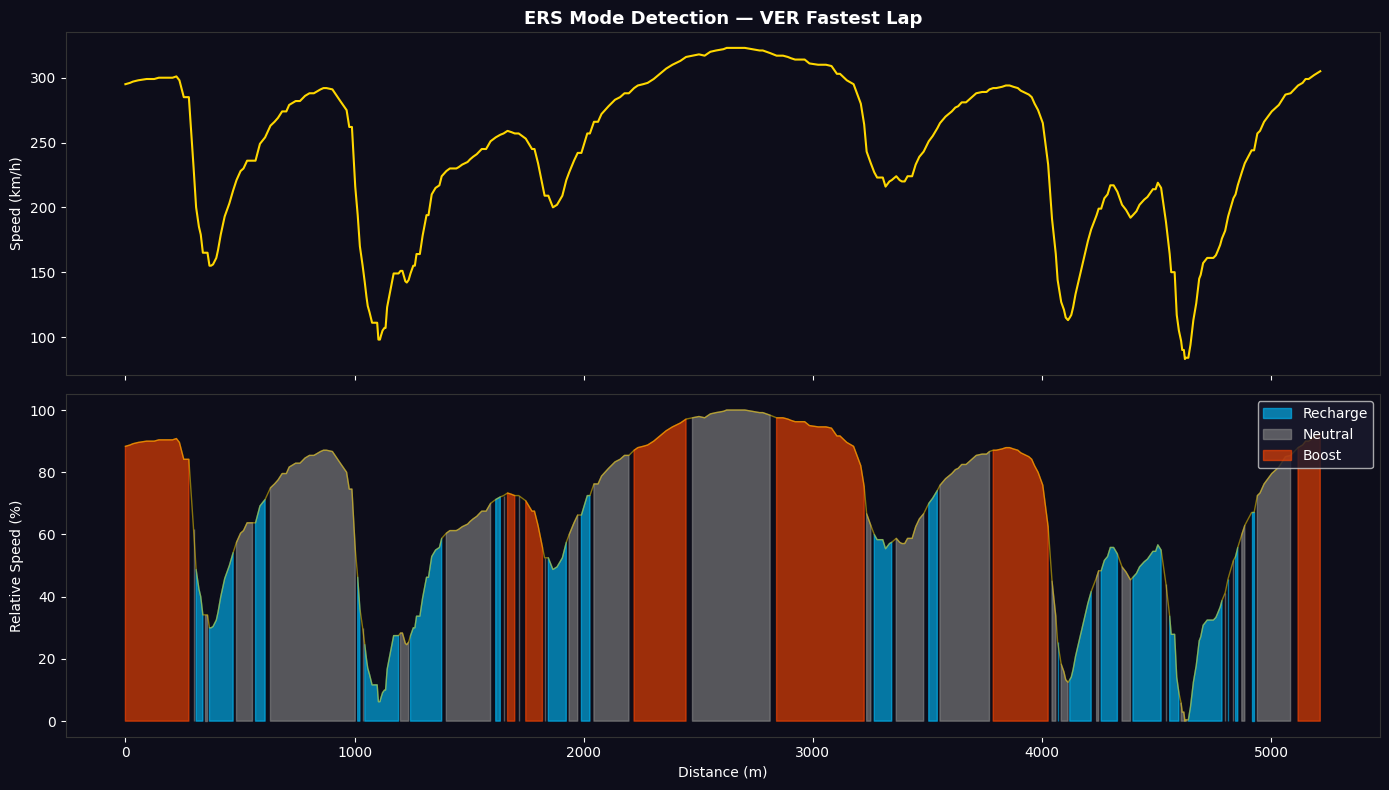

In [12]:
fastest_driver = fastest_per_driver.iloc[0]["Driver"]
fastest_driver_lap = laps.pick_drivers(fastest_driver).pick_fastest()
telemetry = fastest_driver_lap.get_car_data().add_distance()

tel = telemetry.copy()
tel["Speed_norm"] = (tel["Speed"] - tel["Speed"].min()) / (tel["Speed"].max() - tel["Speed"].min())
tel["RPM_norm"] = (tel["RPM"] - tel["RPM"].min()) / (tel["RPM"].max() - tel["RPM"].min())
tel["SpeedRPM_delta"] = tel["Speed_norm"] - tel["RPM_norm"]

tel["ERS_Mode"] = "Neutral"
tel.loc[tel["SpeedRPM_delta"] < -0.15, "ERS_Mode"] = "Recharge"
tel.loc[tel["SpeedRPM_delta"] > 0.15, "ERS_Mode"] = "Boost"

print(tel["ERS_Mode"].value_counts())

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.patch.set_facecolor("#0d0d1a")
ax1.set_facecolor("#0d0d1a")
ax2.set_facecolor("#0d0d1a")

ers_colors = {"Recharge": "#00BFFF", "Neutral": "#888888", "Boost": "#FF4500"}

ax1.plot(tel["Distance"], tel["Speed"], color="#FFD700", linewidth=1.5)
ax1.set_ylabel("Speed (km/h)", color="white")
ax1.set_title(f"ERS Mode Detection — {fastest_driver} Fastest Lap",
              color="white", fontsize=13, fontweight="bold")
ax1.tick_params(colors="white")
ax1.spines[:].set_color("#333")

for mode, color in ers_colors.items():
    mask = tel["ERS_Mode"] == mode
    ax2.fill_between(tel["Distance"], 0, tel["Speed_norm"] * 100,
                     where=mask, alpha=0.6, color=color, label=mode)

ax2.plot(tel["Distance"], tel["Speed_norm"] * 100, 
         color="#FFD700", linewidth=1, alpha=0.5)
ax2.set_ylabel("Relative Speed (%)", color="white")
ax2.set_xlabel("Distance (m)", color="white")
ax2.legend(loc="upper right", facecolor="#1a1a2e", labelcolor="white")
ax2.tick_params(colors="white")
ax2.spines[:].set_color("#333")

plt.tight_layout()
plt.savefig("ers_detection.png", dpi=150, 
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### Observation 💡
The ERS detection chart maps energy recovery and deployment 
directly onto Verstappen's speed trace.

Every braking zone (speed dip) corresponds to a Recharge phase — 
the MGU-K harvesting kinetic energy as the car decelerates into corners. 
Every high speed section (straights) corresponds to a Boost phase — 
the stored electrical energy being deployed for additional acceleration.

This proxy method using Speed vs RPM delta is an approximation since 
2026 regulations restrict direct ERS telemetry. A future improvement 
would be to analyse multiple laps to observe how ERS deployment strategy 
changes in race conditions vs qualifying.